In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_validate, cross_val_predict
from sklearn.metrics import (
  mean_absolute_error,
  mean_squared_error,
  r2_score,
)

In [53]:
model_df = pd.read_parquet("BTC-USDT_features_1min.parquet")

In [54]:
def evaluate_ridge(x, y, alpha=1.0, n_splits=5):
  x = x.replace([np.inf, -np.inf], np.nan).dropna()
  y = y.loc[x.index]

  model = make_pipeline(
      StandardScaler(),
      Ridge(alpha=alpha, solver="svd")
  )
  tscv = TimeSeriesSplit(n_splits=n_splits)

  scoring = {
      "mae": "neg_mean_absolute_error",
      "rmse": "neg_root_mean_squared_error",
      "r2": "r2",
  }

  cv_results = cross_validate(
      model,
      x,
      y,
      cv=tscv,
      scoring=scoring,
      return_train_score=True,
  )

  preds = np.full(len(y), np.nan)
  for train_idx, test_idx in tscv.split(x):
          x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
          y_train = y.iloc[train_idx]

          model.fit(x_train, y_train)
          preds[test_idx] = model.predict(x_test)

  valid = ~np.isnan(preds)

  metrics = {
      "cv_mae_mean": -cv_results["test_mae"].mean(),
      "cv_rmse_mean": -cv_results["test_rmse"].mean(),
      "cv_r2_mean": cv_results["test_r2"].mean(),
      "oos_mae": mean_absolute_error(y.iloc[valid], preds[valid]),
      "oos_rmse": np.sqrt(mean_squared_error(y.iloc[valid], preds[valid])),
      "oos_r2": r2_score(y.iloc[valid], preds[valid]),
  }

  return preds, metrics


def plot_ridge_diagnostics(y, y_pred):
  y = np.asarray(y)
  y_pred = np.asarray(y_pred)
  residuals = y - y_pred

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  axes[0].scatter(y, y_pred, alpha=0.5)
  axes[0].plot([y.min(), y.max()], [y.min(), y.max()], "r--")
  axes[0].set_title("Actual vs Predicted")
  axes[0].set_xlabel("Actual")
  axes[0].set_ylabel("Predicted")

  axes[1].scatter(y_pred, residuals, alpha=0.5)
  axes[1].axhline(0, color="r", linestyle="--")
  axes[1].set_title("Residuals vs Predicted")
  axes[1].set_xlabel("Predicted")
  axes[1].set_ylabel("Residuals")

  plt.tight_layout()
  plt.show()

def plot_volume_vs_predicted_over_time(model_df, y_pred, time_col=None, n_points=2000):
  df_plot = model_df.copy()

  if time_col is not None:
      time_index = pd.to_datetime(df_plot[time_col])
  elif isinstance(df_plot.index, pd.DatetimeIndex):
      time_index = df_plot.index
  else:
      time_index = pd.RangeIndex(len(df_plot))

  df_plot = df_plot.loc[df_plot["volume"].replace([np.inf, -np.inf], np.nan).notna()].copy()
  df_plot = df_plot.iloc[:len(y_pred)].copy()

  df_plot["predicted_volume"] = y_pred
  df_plot["time"] = time_index[:len(df_plot)]

  sample = df_plot.iloc[:n_points]

  plt.figure(figsize=(16, 6))
  plt.plot(sample["time"], sample["volume"], label="Actual Volume", linewidth=1.5)
  plt.plot(sample["time"], sample["predicted_volume"], label="Predicted Volume", linewidth=1.5, alpha=0.8)
  plt.title(f"Actual vs Predicted Volume Over Time (first {len(sample)} rows)")
  plt.xlabel("Time")
  plt.ylabel("Volume")
  plt.legend()
  plt.tight_layout()
  plt.show()

{'cv_mae_mean': np.float64(12.561212717593584), 'cv_rmse_mean': np.float64(52.270742266317484), 'cv_r2_mean': np.float64(0.9978780590050276), 'oos_mae': 12.561212717593586, 'oos_rmse': np.float64(57.3557738341614), 'oos_r2': 0.9979460466434386}


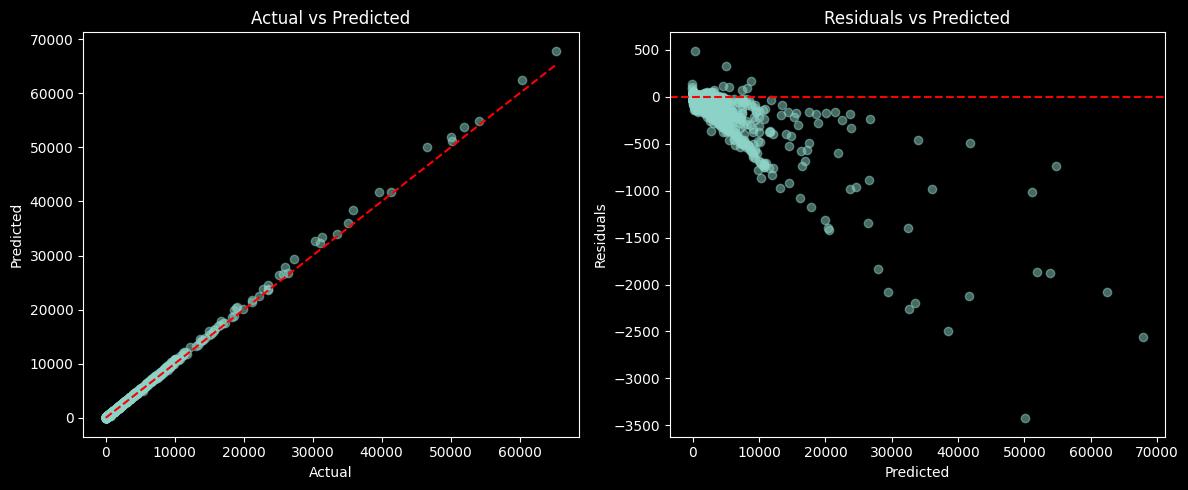

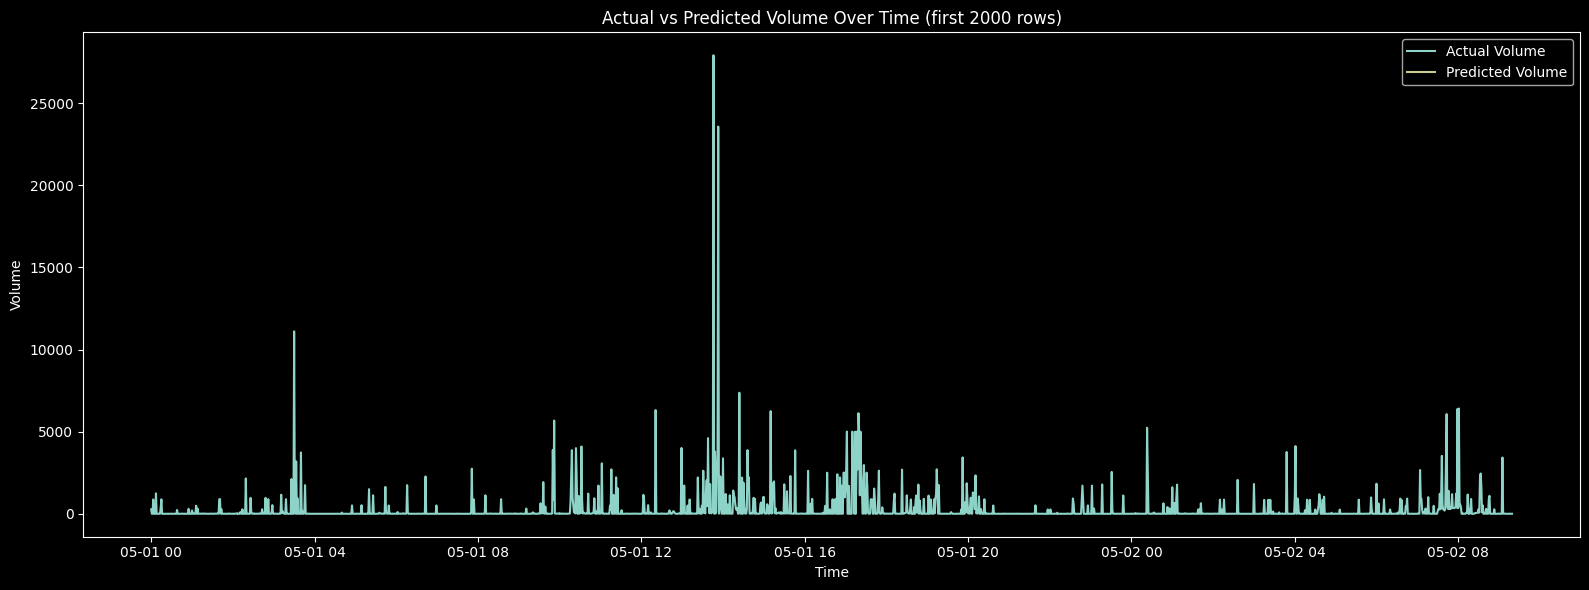

In [55]:
y = model_df["volume"]
x = model_df.drop("volume", axis=1)

y_pred, metrics = evaluate_ridge(x, y, alpha=10.0, n_splits=5)
print(metrics)
plot_ridge_diagnostics(y, y_pred)
plot_volume_vs_predicted_over_time(model_df, y_pred, n_points=2000)